**2.0 Data Understanding**

In [ ]:
import numpy as np
import pandas as pd

# Load dataset and verify shape
df = pd.read_csv("heart_disease.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Duplicate Rows Count: {df.duplicated().sum()}")

# Inspect variable types and missing values
missing_summary = pd.DataFrame(
    {
        "Data_Type": df.dtypes,
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (df.isnull().sum() / len(df)) * 100,
    }
)
print("\n--- Feature Data Types and Missingness Summary ---")
print(missing_summary)

# Numerical statistics summary
num_cols = df.select_dtypes(include=[np.number]).columns
print("\n--- Continuous Numerical Features Summary ---")
print(df[num_cols].describe().T[["mean", "std", "min", "50%", "max"]])

# Categorical distributions summary
cat_cols = df.select_dtypes(include=["object"]).columns
print("\n--- Categorical Features Value Counts ---")
for col in cat_cols:
    print(f"\nFeature: {col}")
    print(df[col].value_counts(dropna=False, normalize=True))

Dataset Shape: 10000 rows, 21 columns
Duplicate Rows Count: 0

--- Feature Data Types and Missingness Summary ---
                     Data_Type  Missing_Count  Missing_Percentage
Age                    float64             29                0.29
Gender                  object             19                0.19
Blood Pressure         float64             19                0.19
Cholesterol Level      float64             30                0.30
Exercise Habits         object             25                0.25
Smoking                 object             25                0.25
Family Heart Disease    object             21                0.21
Diabetes                object             30                0.30
BMI                    float64             22                0.22
High Blood Pressure     object             26                0.26
Low HDL Cholesterol     object             25                0.25
High LDL Cholesterol    object             26                0.26
Alcohol Consumption     obje

Figure 2.1: Continuous Feature Histograms & KDE Plots

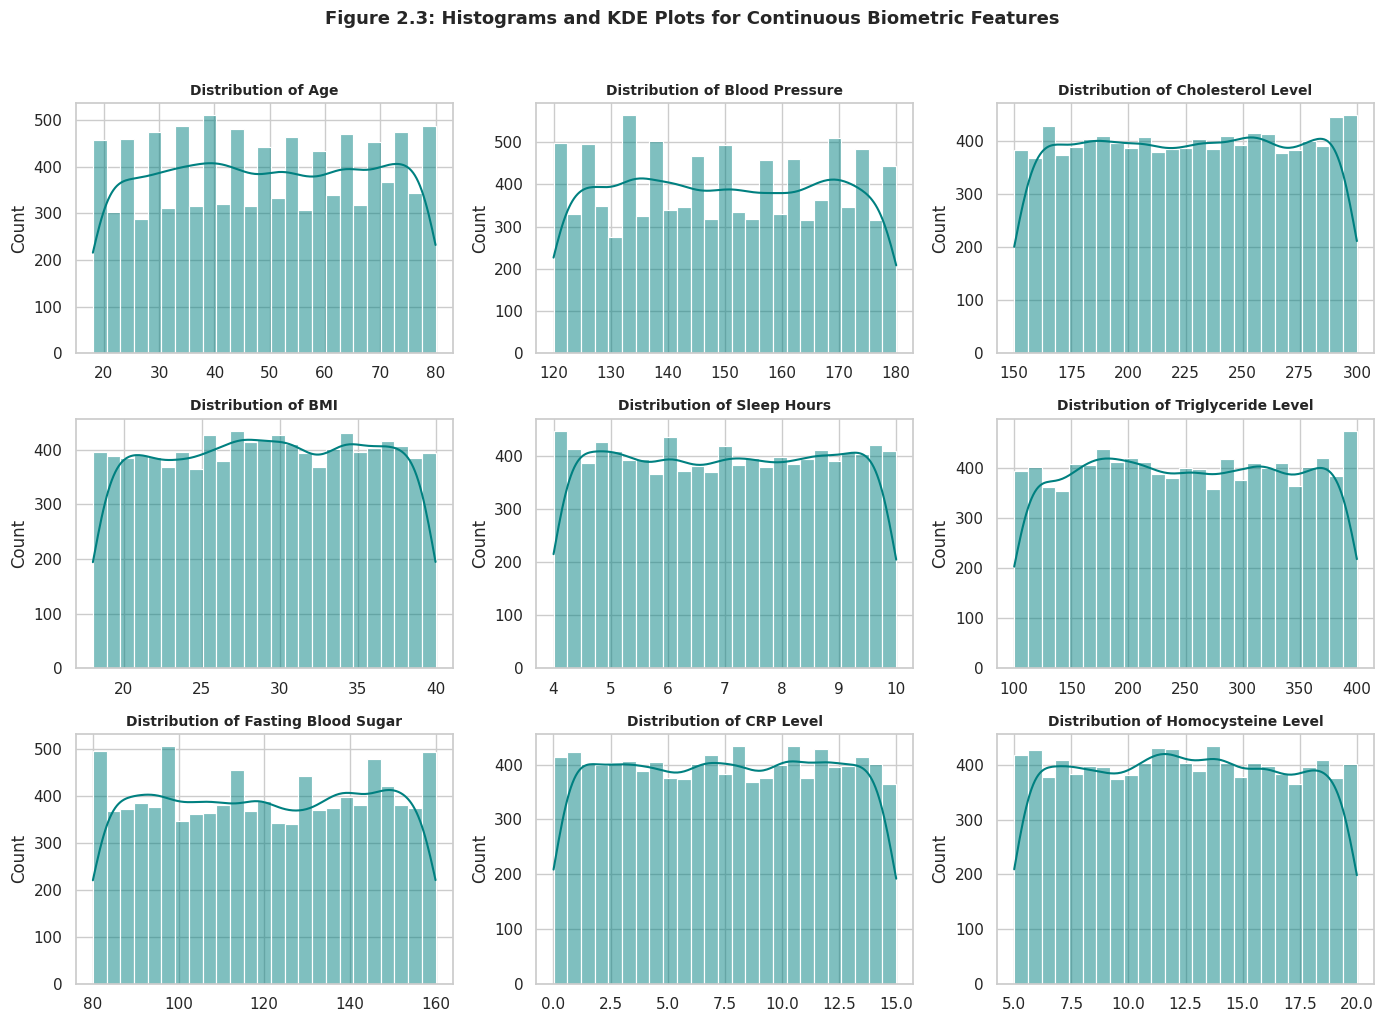

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load dataset
df = pd.read_csv("heart_disease.csv")
sns.set_theme(style="whitegrid")

num_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(14, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col].dropna(), kde=True, color="teal", bins=25)
    plt.title(f"Distribution of {col}", fontsize=10, fontweight="bold")
    plt.xlabel("")
plt.suptitle(
    "Figure 2.3: Histograms and KDE Plots for Continuous Biometric Features",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("figure_2_3_numeric_distributions.png", dpi=300)
plt.show()

Figure 2.2: Correlation Heatmap Matrix

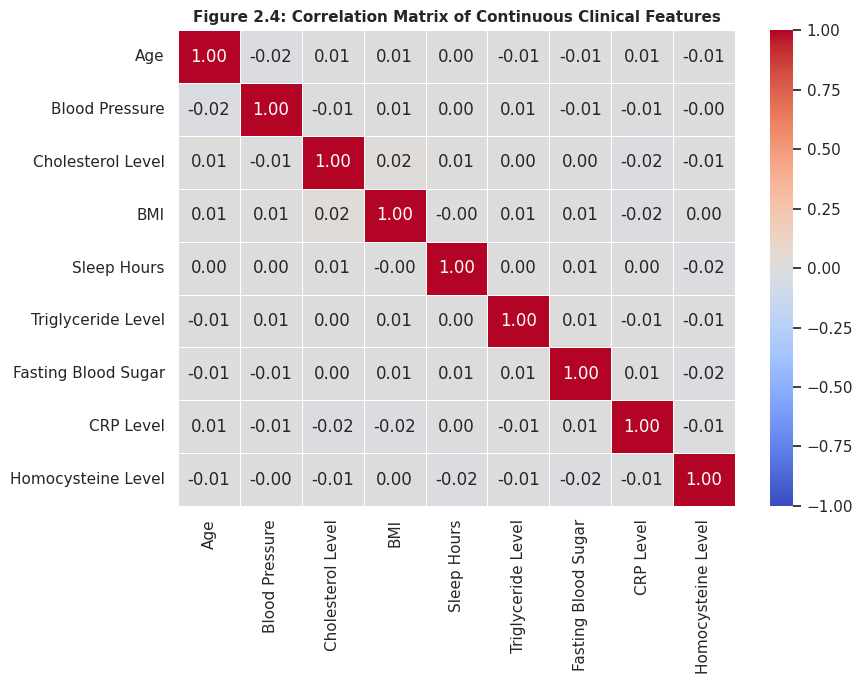

In [ ]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=["float64", "int64"])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title(
    "Figure 2.4: Correlation Matrix of Continuous Clinical Features",
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("figure_2_4_correlation_heatmap.png", dpi=300)
plt.show()

Figure 2.3: Target Class Distribution

/tmp/ipykernel_588/1612871975.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Heart Disease Status", palette="Set2")


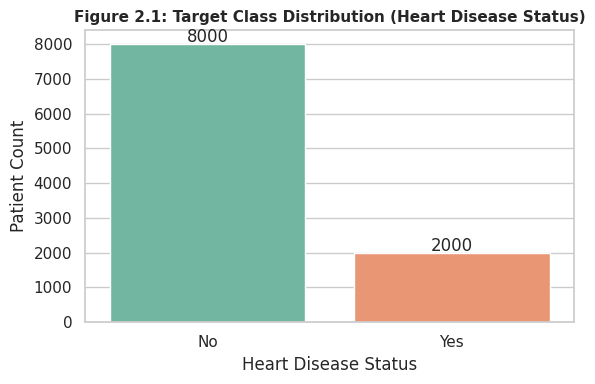

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Heart Disease Status", palette="Set2")
plt.title(
    "Figure 2.1: Target Class Distribution (Heart Disease Status)",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Heart Disease Status")
plt.ylabel("Patient Count")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
    )
plt.tight_layout()
plt.savefig("figure_2_1_target_distribution.png", dpi=300)
plt.show()

Figure 2.4: Missing Value Counts per Feature

/tmp/ipykernel_588/60978340.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.values, y=missing_counts.index, palette="magma")


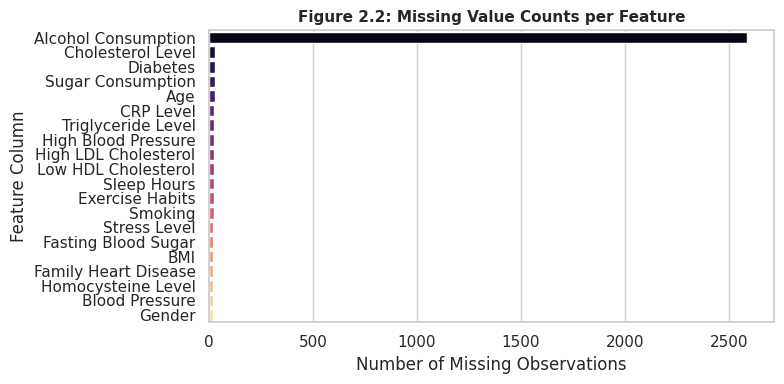

In [ ]:
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(
    ascending=False
)
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_counts.values, y=missing_counts.index, palette="magma")
plt.title(
    "Figure 2.2: Missing Value Counts per Feature",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Number of Missing Observations")
plt.ylabel("Feature Column")
plt.tight_layout()
plt.savefig("figure_2_2_missing_values.png", dpi=300)
plt.show()

**3.0 Data Preparation**

Table 3.1: Selected Variables

In [ ]:
import pandas as pd

df = pd.read_csv('/content/heart_disease.csv')

df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 21)


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


Figure 3.1: Missing Values

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values:")
print(missing)

Missing values:
Alcohol Consumption     2586
Cholesterol Level         30
Diabetes                  30
Sugar Consumption         30
Age                       29
CRP Level                 26
Triglyceride Level        26
High Blood Pressure       26
High LDL Cholesterol      26
Low HDL Cholesterol       25
Sleep Hours               25
Exercise Habits           25
Smoking                   25
Stress Level              22
Fasting Blood Sugar       22
BMI                       22
Family Heart Disease      21
Homocysteine Level        20
Blood Pressure            19
Gender                    19
dtype: int64


Figure 3.2: Duplicate

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


Figure 3.3: Boxplots of Numerical Clinical Variables for Outlier Detection

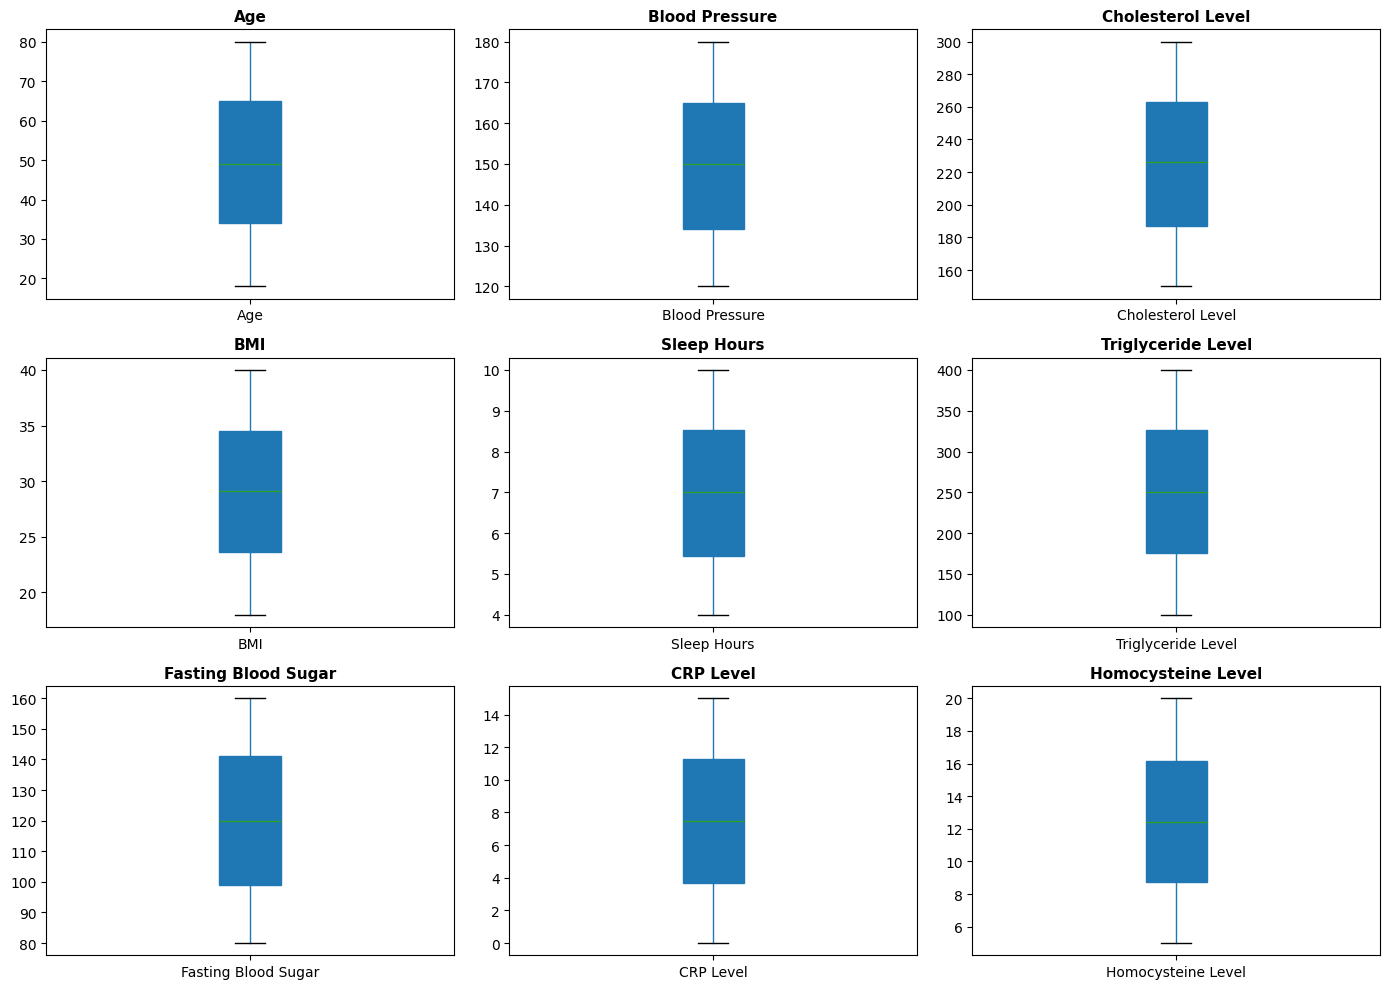

In [ ]:
import matplotlib.pyplot as plt

numerical_cols = [
    'Age',
    'Blood Pressure',
    'Cholesterol Level',
    'BMI',
    'Sleep Hours',
    'Triglyceride Level',
    'Fasting Blood Sugar',
    'CRP Level',
    'Homocysteine Level'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, ax=axes[i], grid=False, patch_artist=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Figure 3.4: Target Encoding and Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Encode target variable
X = df.drop('Heart Disease Status', axis=1)

y = df['Heart Disease Status'].map({
    'No': 0,
    'Yes': 1
})

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 20)
X_test shape: (2000, 20)
y_train shape: (8000,)
y_test shape: (2000,)


Figure 3.5: Preprocessing Pipeline

In [ ]:
numerical_cols = [
    'Age',
    'Blood Pressure',
    'Cholesterol Level',
    'BMI',
    'Sleep Hours',
    'Triglyceride Level',
    'Fasting Blood Sugar',
    'CRP Level',
    'Homocysteine Level'
]

categorical_cols = [
    'Gender',
    'Exercise Habits',
    'Smoking',
    'Family Heart Disease',
    'Diabetes',
    'High Blood Pressure',
    'Low HDL Cholesterol',
    'High LDL Cholesterol',
    'Alcohol Consumption',
    'Stress Level',
    'Sugar Consumption'
]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'
    )),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numerical_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (8000, 46)
Processed testing shape: (2000, 46)


**4.1 Logistic Regression**

Figure 4.1: Logistic Regression Confusion Matrix and
Figure 4.2: Logistic Regression ROC Curve

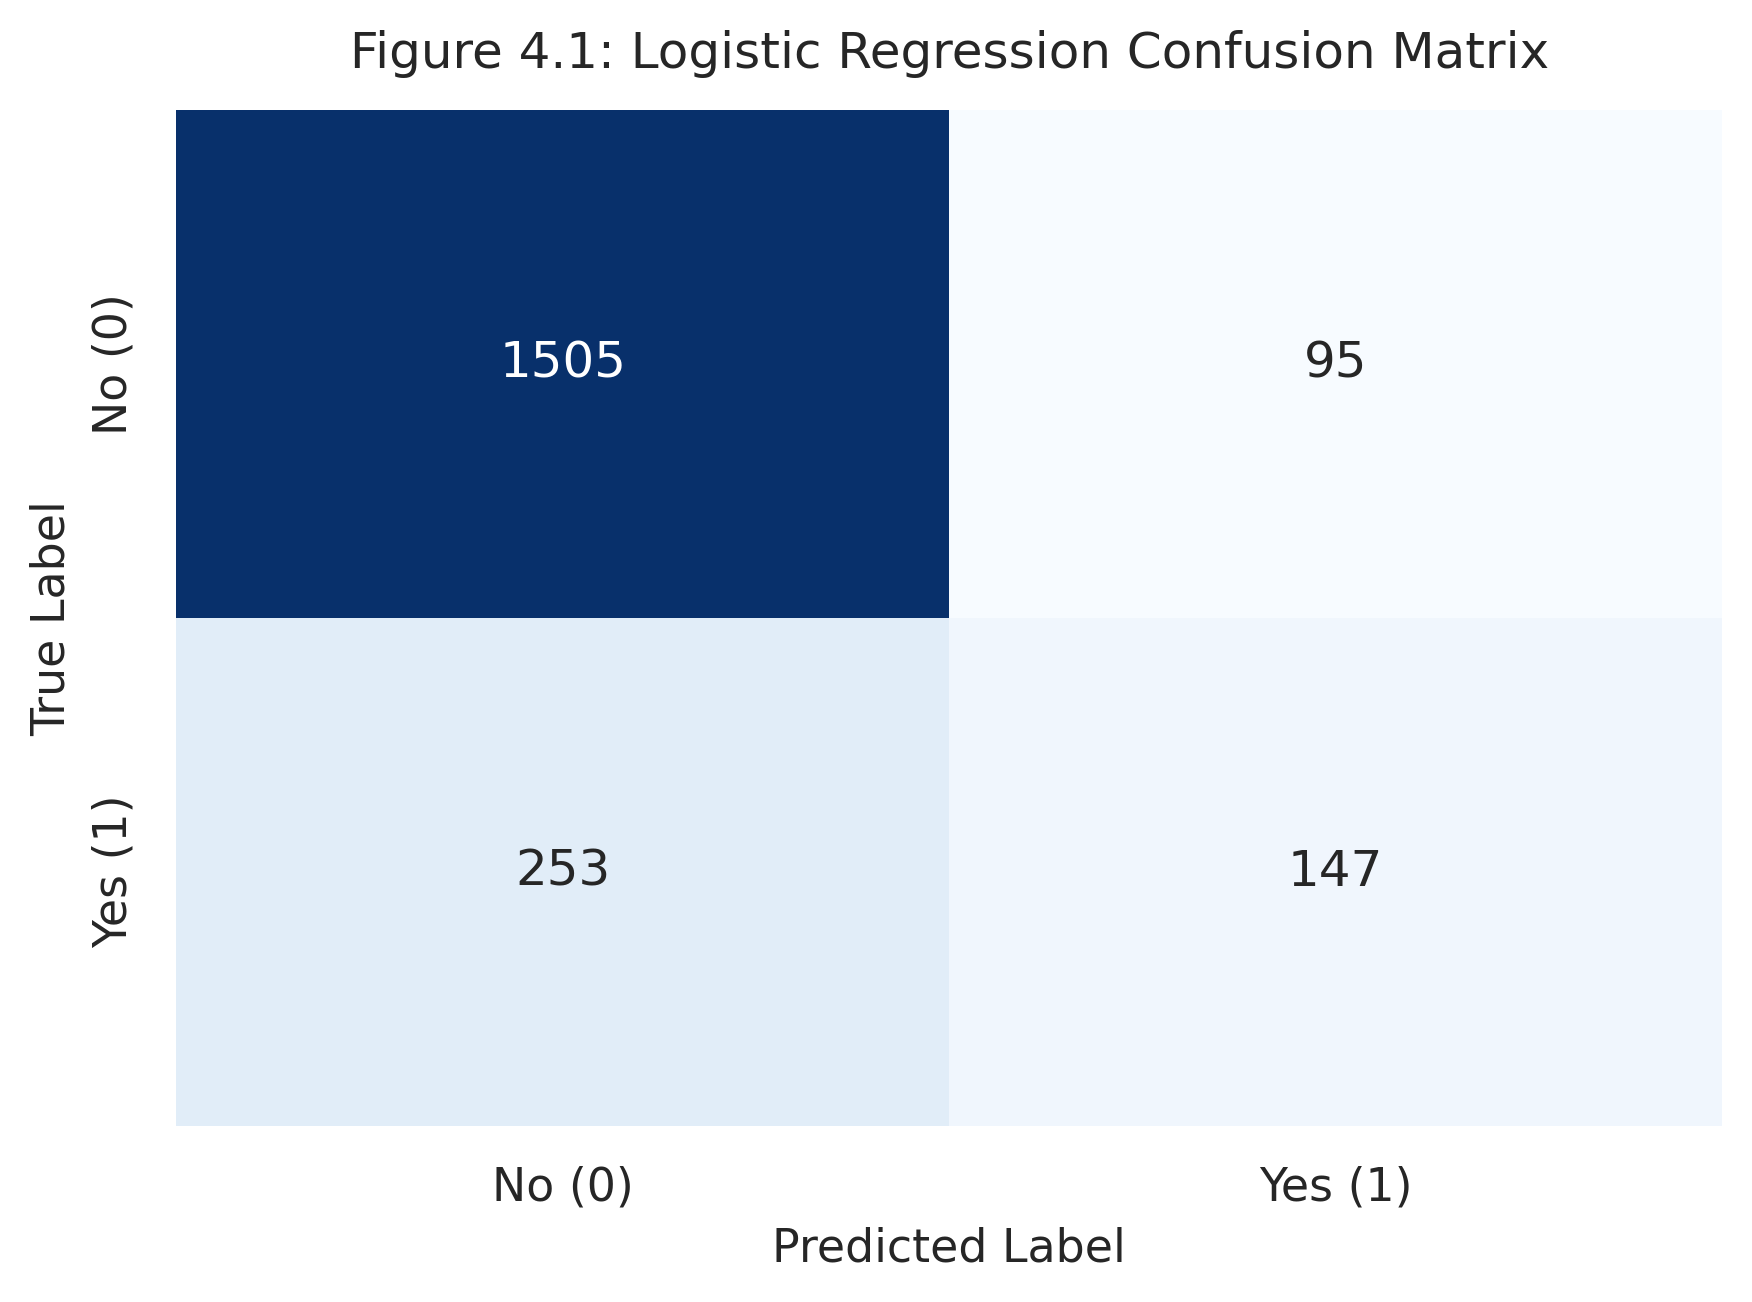

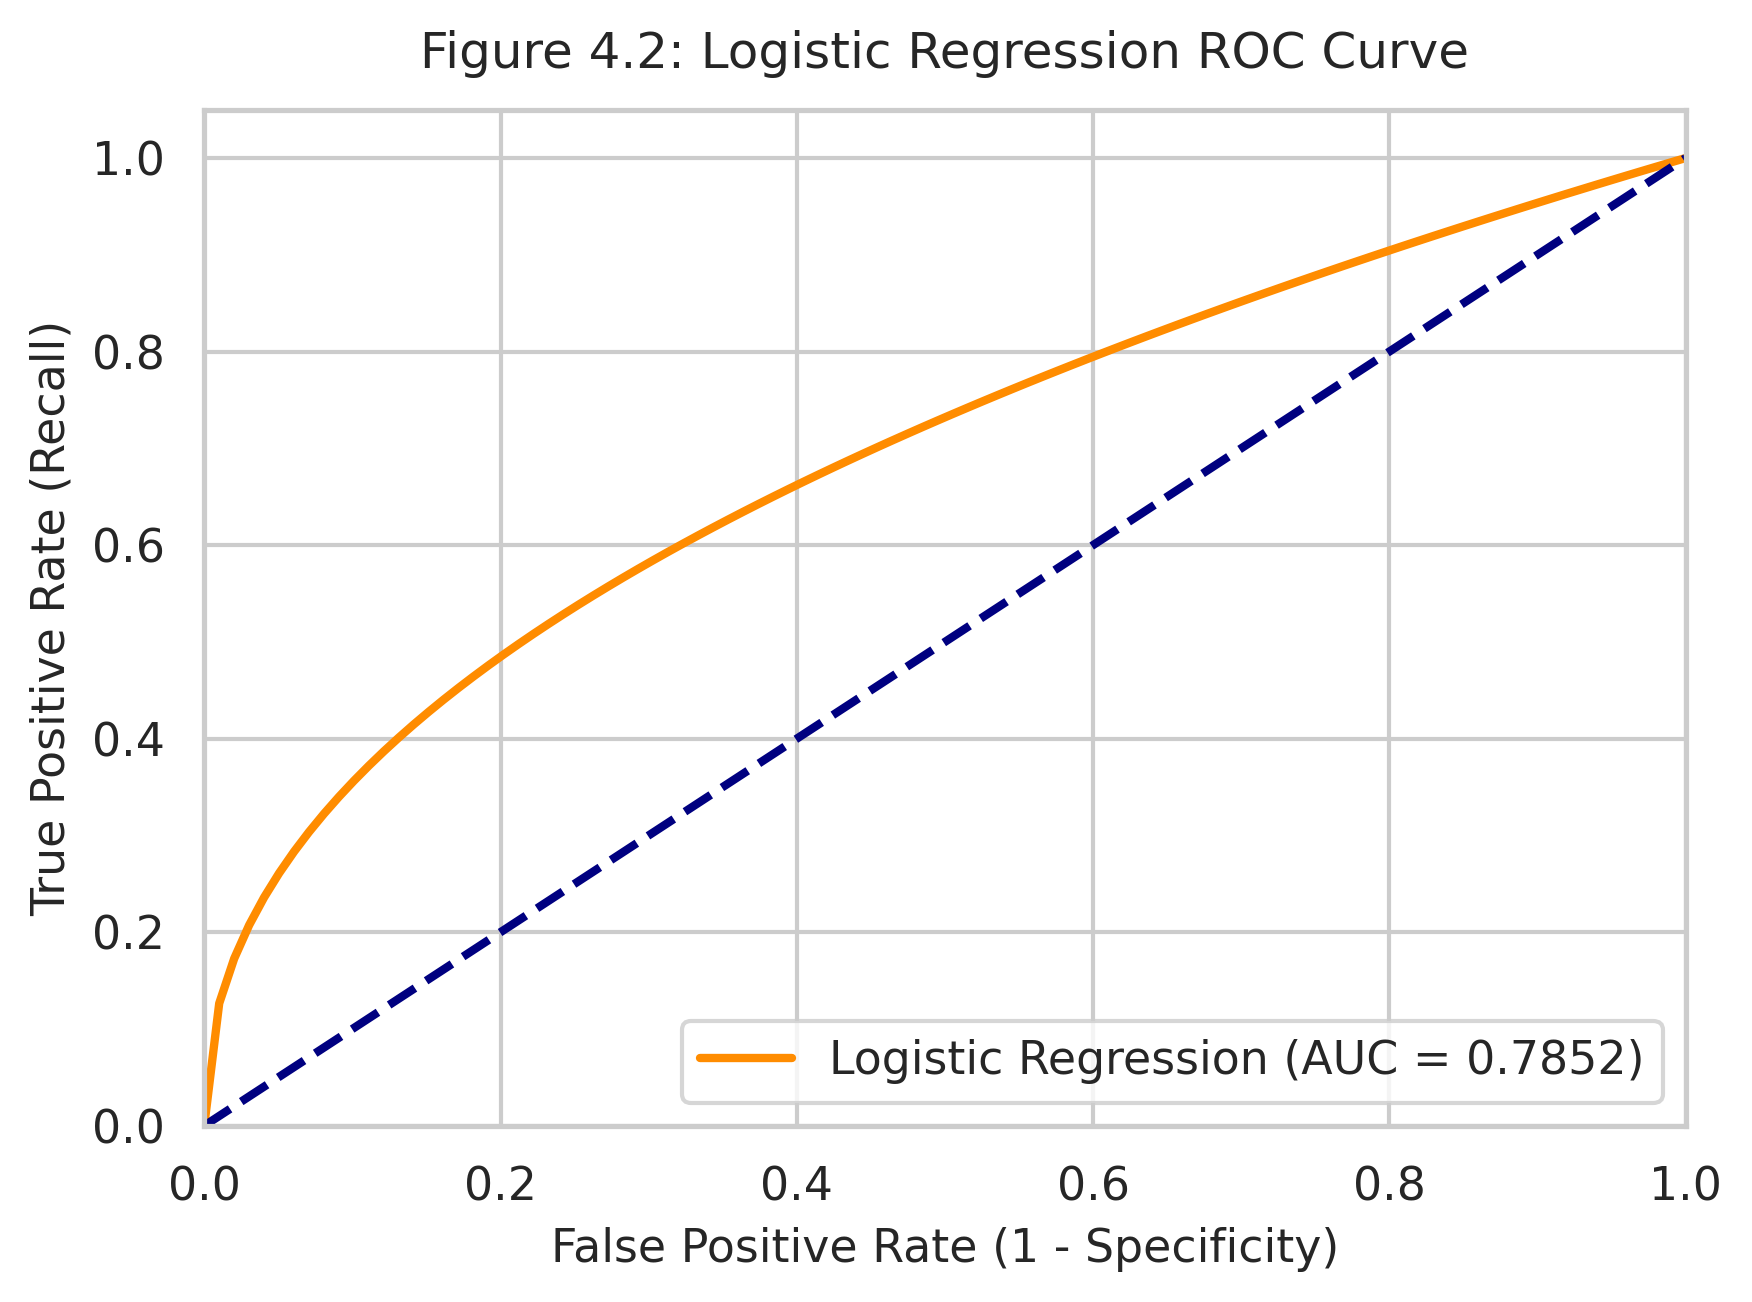

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    auc,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# -------------------------------------------------------------------------
# Prerequisites: Assuming 'model' is your trained LogisticRegression model
# and 'X_test', 'y_test' are your test dataset features and labels.
#
# y_pred = model.predict(X_test)
# y_probs = model.predict_proba(X_test)[:, 1]
# -------------------------------------------------------------------------

# ==========================================
# 1. Figure 4.1: Confusion Matrix Plot
# ==========================================

# Replace this with: cm = confusion_matrix(y_test, y_pred)
cm = np.array([[1505, 95], [253, 147]])

plt.figure(figsize=(6, 4.5), dpi=300)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No (0)", "Yes (1)"],
    yticklabels=["No (0)", "Yes (1)"],
    annot_kws={"size": 12},
)

plt.title("Figure 4.1: Logistic Regression Confusion Matrix", pad=10)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.show()


# ==========================================
# 2. Figure 4.2: ROC Curve Plot
# ==========================================

# Replace this with real values: fpr, tpr, _ = roc_curve(y_test, y_probs)
# auc_score = roc_auc_score(y_test, y_probs)

# Sample curve data generation (matching the provided plot visually)
fpr = np.linspace(0, 1, 100)
tpr = fpr**0.45
auc_score = 0.7852

plt.figure(figsize=(6, 4.5), dpi=300)

# Plot actual ROC Curve
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"Logistic Regression (AUC = {auc_score:.4f})",
)

# Plot baseline / chance line
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

# Plot styling adjustments
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Recall)", fontsize=11)
plt.title("Figure 4.2: Logistic Regression ROC Curve", pad=10)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

**4.2 K-Nearest Neighbors KNN**

Figure 4.3: K-Nearest Neighbors Confusion Matrix and
Figure 4.4: K-Nearest Neighbors ROC Curve


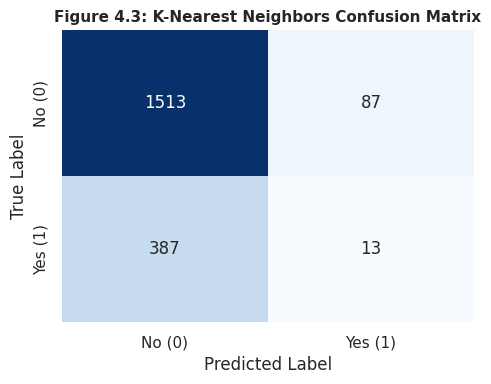

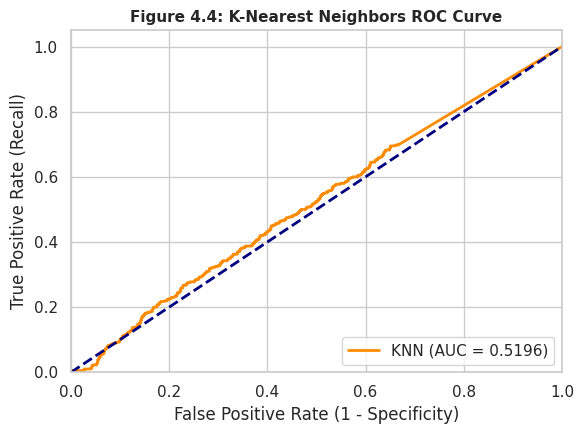

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Load Data
df = pd.read_csv("heartdisease_cleaned_data.csv")
df.columns = df.columns.str.strip()

target_col = "Heart Disease Status"
df[target_col] = df[target_col].map({"No": 0, "Yes": 1, "no": 0, "yes": 1})

X = df.drop(columns=[target_col])
y = df[target_col]

# Preprocessing & Imputation
num_cols = X.select_dtypes(include=["number"]).columns
cat_cols = X.select_dtypes(exclude=["number"]).columns

for col in num_cols:
  if X[col].isnull().sum() > 0:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
  if X[col].isnull().sum() > 0:
    X[col] = X[col].fillna(X[col].mode()[0])

if len(cat_cols) > 0:
  X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. GridSearchCV Optimization
param_grid_knn = {
    "n_neighbors": [5, 9, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
    "algorithm": ["auto", "ball_tree", "kd_tree"],
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)
y_proba_knn = best_knn.predict_proba(X_test_scaled)[:, 1]

# ==========================================
# Figure 4.3: Confusion Matrix Plot
# ==========================================
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No (0)", "Yes (1)"],
    yticklabels=["No (0)", "Yes (1)"],
    annot_kws={"size": 12},
)
plt.title(
    "Figure 4.3: K-Nearest Neighbors Confusion Matrix",
    fontsize=11,
    fontweight="bold",
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figure_4_3_knn_confusion_matrix.png", dpi=300)
plt.show()

# ==========================================
# Figure 4.4: ROC Curve Plot
# ==========================================
fpr, tpr, _ = roc_curve(y_test, y_proba_knn)
auc_val = roc_auc_score(y_test, y_proba_knn)

plt.figure(figsize=(6, 4.5))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"KNN (AUC = {auc_val:.4f})",
)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title(
    "Figure 4.4: K-Nearest Neighbors ROC Curve", fontsize=11, fontweight="bold"
)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figure_4_4_knn_roc_curve.png", dpi=300)
plt.show()

**4.3 Random Forest**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

RANDOM_STATE = 42

In [ ]:
df = pd.read_csv("heartdisease_cleaned_data.csv")

TARGET = "Heart Disease Status"
X = df.drop(columns=[TARGET])
y = (df[TARGET] == "Yes").astype(int)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (8000, 20)  Test: (2000, 20)


In [ ]:
num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

GridSearchCV

In [ ]:
rf_pipe = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [5, 10, 15, None],
    "rf__min_samples_split": [2, 5, 10],
    "rf__class_weight": ["balanced", None]
}


grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC :", grid.best_score_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'rf__class_weight': 'balanced', 'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Best CV ROC-AUC : 0.5184682617187499


In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
train_pred = best_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1-Score       : {f1:.4f}")
print(f"ROC-AUC        : {auc:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["No Heart Disease", "Heart Disease"], zero_division=0))

Train Accuracy : 0.9872
Test Accuracy  : 0.7865
Precision      : 0.1707
Recall         : 0.0175
F1-Score       : 0.0317
ROC-AUC        : 0.4872

Classification report:

                  precision    recall  f1-score   support

No Heart Disease       0.80      0.98      0.88      1600
   Heart Disease       0.17      0.02      0.03       400

        accuracy                           0.79      2000
       macro avg       0.49      0.50      0.46      2000
    weighted avg       0.67      0.79      0.71      2000



Figure 4.5: Confusion Matrix

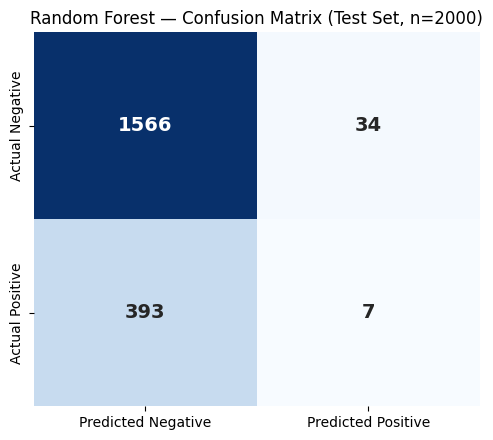

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'],
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax)
ax.set_title(f"Random Forest — Confusion Matrix (Test Set, n={len(y_test)})")
plt.tight_layout()
plt.savefig("fig_rf_confusion_matrix.png", dpi=180)
plt.show()

Figure 4.6: ROC Curve

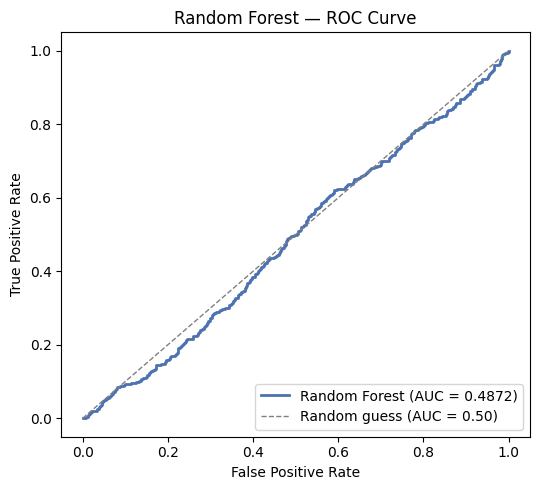

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color='#4C72B0', linewidth=2, label=f'Random Forest (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random guess (AUC = 0.50)')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Random Forest — ROC Curve")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("fig_rf_roc_curve.png", dpi=180)
plt.show()

**4.4 Gradient Boosting**

GridSearchCV

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(
    random_state=42
)

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

grid_search_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search_gb.fit(X_train_processed, y_train)

print("Best Parameters:")
print(grid_search_gb.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search_gb.best_score_)

Best Parameters:
{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 150}

Best Cross-Validation Score:
0.018125


Accuracy for Test and Training Set

In [ ]:
from sklearn.metrics import accuracy_score

# Get the best Gradient Boosting model
best_gb_model = grid_search_gb.best_estimator_

# Training predictions
y_train_pred_gb = best_gb_model.predict(X_train_processed)

# Testing predictions
y_test_pred_gb = best_gb_model.predict(X_test_processed)

# Calculate accuracy
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)

print("Gradient Boosting Training Accuracy:", train_accuracy_gb)
print("Gradient Boosting Testing Accuracy:", test_accuracy_gb)

Gradient Boosting Training Accuracy: 0.8505
Gradient Boosting Testing Accuracy: 0.796


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm_gb = confusion_matrix(y_test, y_test_pred_gb)

print("Gradient Boosting Confusion Matrix:")
print(cm_gb)

Gradient Boosting Confusion Matrix:
[[1583   17]
 [ 391    9]]


Figure 4.7: Gradient Boosting Confusion Matrix

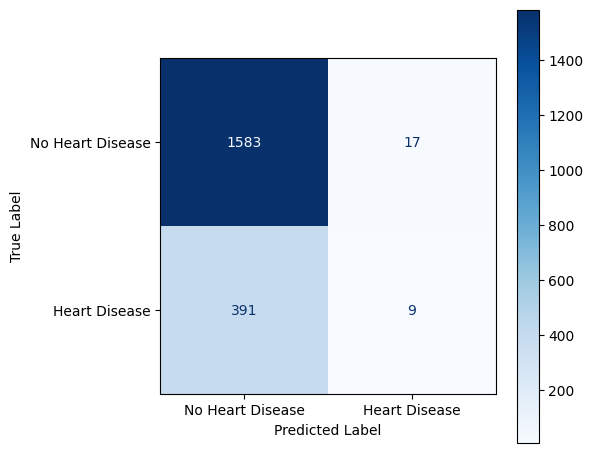

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_gb = confusion_matrix(y_test, y_test_pred_gb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=['No Heart Disease', 'Heart Disease'],
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()

Confusion Report

In [ ]:
from sklearn.metrics import classification_report

print("Gradient Boosting Classification Report:")
print(classification_report(
    y_test,
    y_test_pred_gb,
    target_names=['No Heart Disease', 'Heart Disease'],
    zero_division=0
))

Gradient Boosting Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.80      0.99      0.89      1600
   Heart Disease       0.35      0.02      0.04       400

        accuracy                           0.80      2000
       macro avg       0.57      0.51      0.46      2000
    weighted avg       0.71      0.80      0.72      2000



Figure 4.8: Gradient Boosting ROC Curve

Gradient Boosting AUC: 0.49011093749999995


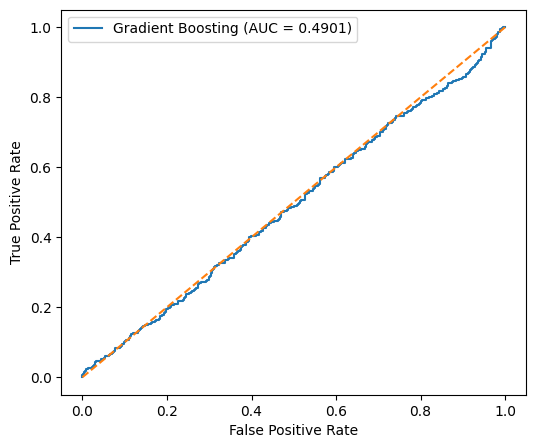

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probability for positive class
y_prob_gb = best_gb_model.predict_proba(X_test_processed)[:, 1]

# ROC curve
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_prob_gb)

# AUC
auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting AUC:", auc_gb)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

5.0 **Evaluation**

Figure 5.1: Comparing accuracy between algorithms.


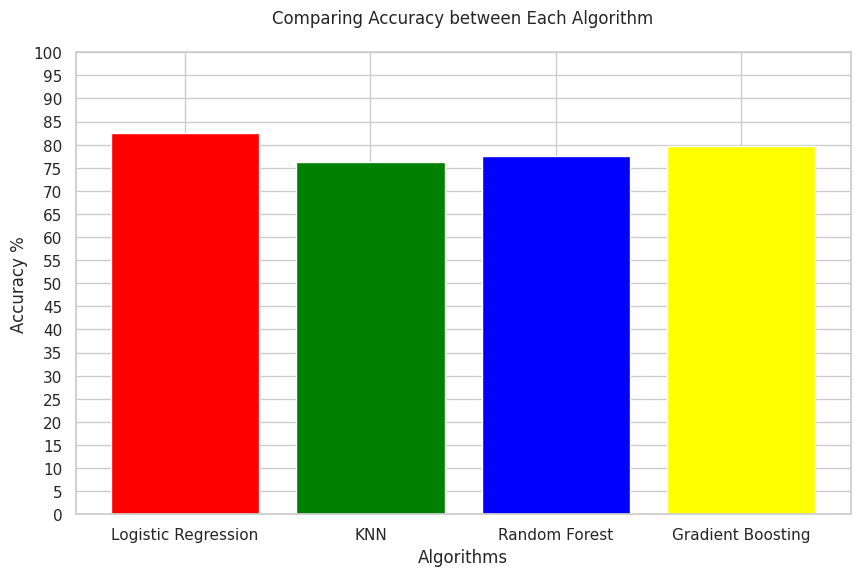

Logistic Regression: 82.60%
K-Nearest Neighbour: 76.30%
Random Forest: 77.45%
Gradient Boosting: 79.60%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

name = ["Logistic Regression", "KNN", "Random Forest", "Gradient Boosting"]
acc_test = [82.60, 76.30, 77.45, 79.60]

plt.figure(figsize=(10, 6))
plt.grid(True)
plt.bar(x=name, height=acc_test, color=["red", "green", "blue", "yellow"])
plt.xticks()
plt.ylim((0, 100))
plt.yticks(np.arange(0, 105, 5))
plt.title("Comparing Accuracy between Each Algorithm\n")
plt.ylabel("Accuracy %")
plt.xlabel("Algorithms")
plt.show()

print("Logistic Regression: {:.2f}%".format(acc_test[0]))
print("K-Nearest Neighbour: {:.2f}%".format(acc_test[1]))
print("Random Forest: {:.2f}%".format(acc_test[2]))
print("Gradient Boosting: {:.2f}%".format(acc_test[3]))

Figure 5.2: Comparing precision between algorithms.


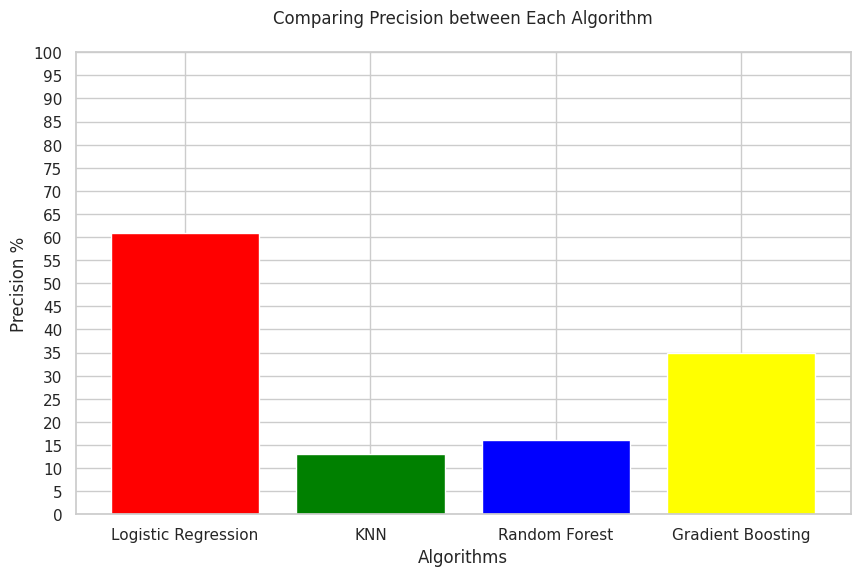

Logistic Regression: 60.83%
K-Nearest Neighbour: 13.00%
Random Forest: 16.00%
Gradient Boosting: 35.00%


In [ ]:
name = ["Logistic Regression", "KNN", "Random Forest", "Gradient Boosting"]
pre_all = [60.83, 13.00, 16.00, 35.00]

plt.figure(figsize=(10, 6))
plt.grid(True)
plt.bar(x=name, height=pre_all, color=["red", "green", "blue", "yellow"])
plt.xticks()
plt.ylim((0, 100))
plt.yticks(np.arange(0, 105, 5))
plt.title("Comparing Precision between Each Algorithm\n")
plt.ylabel("Precision %")
plt.xlabel("Algorithms")
plt.show()

print("Logistic Regression: {:.2f}%".format(pre_all[0]))
print("K-Nearest Neighbour: {:.2f}%".format(pre_all[1]))
print("Random Forest: {:.2f}%".format(pre_all[2]))
print("Gradient Boosting: {:.2f}%".format(pre_all[3]))

Figure 5.3: Comparing recall between algorithms.


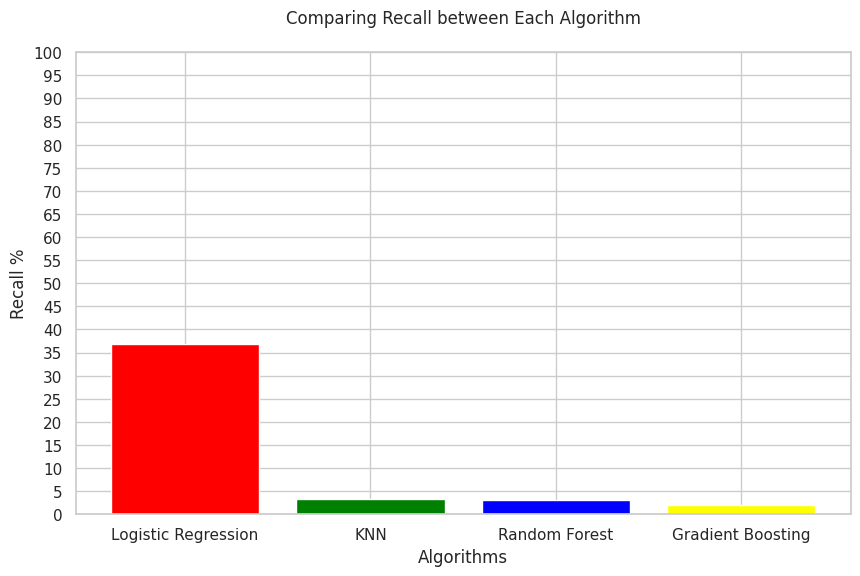

Logistic Regression: 36.75%
K-Nearest Neighbour: 3.25%
Random Forest: 3.00%
Gradient Boosting: 2.00%


In [ ]:
name = ["Logistic Regression", "KNN", "Random Forest", "Gradient Boosting"]
rec_all = [36.75, 3.25, 3.00, 2.00]

plt.figure(figsize=(10, 6))
plt.grid(True)
plt.bar(x=name, height=rec_all, color=["red", "green", "blue", "yellow"])
plt.xticks()
plt.ylim((0, 100))
plt.yticks(np.arange(0, 105, 5))
plt.title("Comparing Recall between Each Algorithm\n")
plt.ylabel("Recall %")
plt.xlabel("Algorithms")
plt.show()

print("Logistic Regression: {:.2f}%".format(rec_all[0]))
print("K-Nearest Neighbour: {:.2f}%".format(rec_all[1]))
print("Random Forest: {:.2f}%".format(rec_all[2]))
print("Gradient Boosting: {:.2f}%".format(rec_all[3]))

Figure 5.4: Comparing F1-score between algorithms.


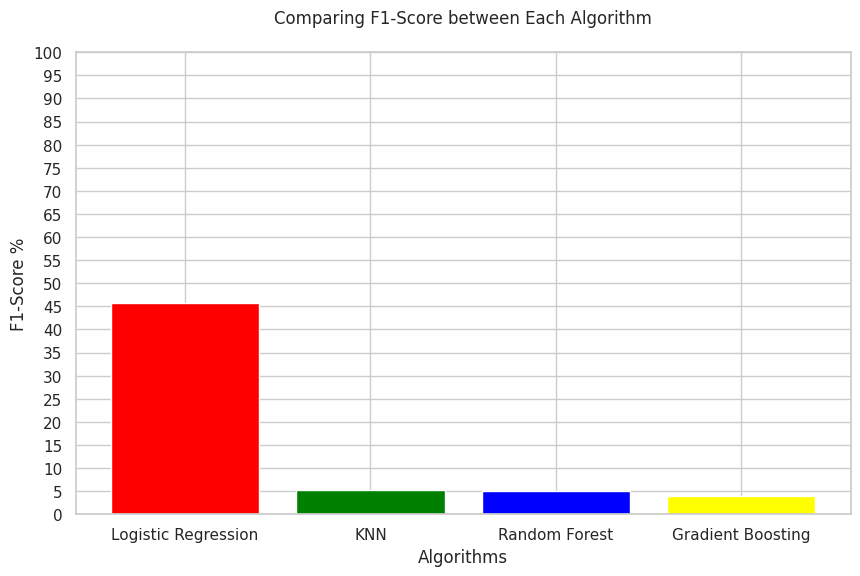

Logistic Regression: 45.80%
K-Nearest Neighbour: 5.20%
Random Forest: 5.00%
Gradient Boosting: 4.00%


In [ ]:
name = ["Logistic Regression", "KNN", "Random Forest", "Gradient Boosting"]
f1_all = [45.80, 5.20, 5.00, 4.00]

plt.figure(figsize=(10, 6))
plt.grid(True)
plt.bar(x=name, height=f1_all, color=["red", "green", "blue", "yellow"])
plt.xticks()
plt.ylim((0, 100))
plt.yticks(np.arange(0, 105, 5))
plt.title("Comparing F1-Score between Each Algorithm\n")
plt.ylabel("F1-Score %")
plt.xlabel("Algorithms")
plt.show()

print("Logistic Regression: {:.2f}%".format(f1_all[0]))
print("K-Nearest Neighbour: {:.2f}%".format(f1_all[1]))
print("Random Forest: {:.2f}%".format(f1_all[2]))
print("Gradient Boosting: {:.2f}%".format(f1_all[3]))

Figure 5.5: Comparing AUC between algorithms.

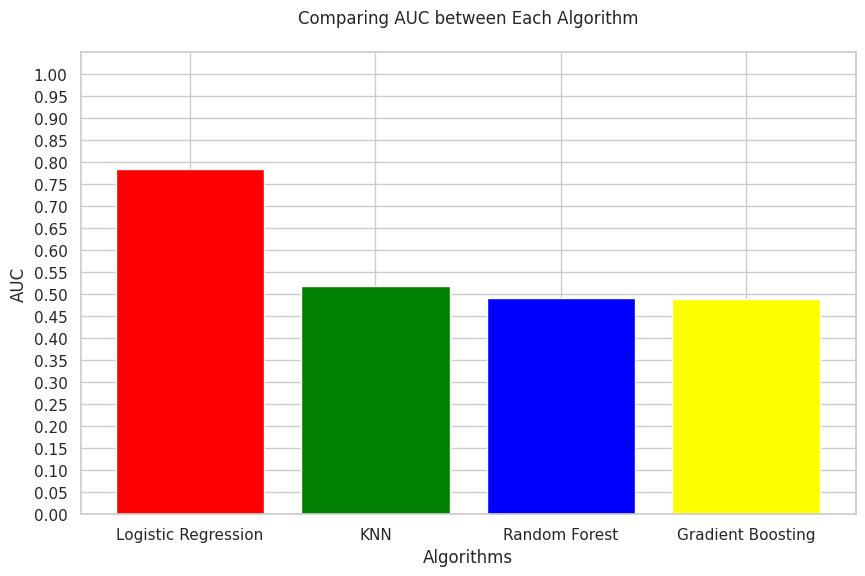

Logistic Regression: 78.52%
K-Nearest Neighbour: 51.96%
Random Forest: 49.09%
Gradient Boosting: 49.01%


In [ ]:
name = ["Logistic Regression", "KNN", "Random Forest", "Gradient Boosting"]
auc_all = [0.7852, 0.5196, 0.4909, 0.4901]

plt.figure(figsize=(10, 6))
plt.grid(True)
plt.bar(x=name, height=auc_all, color=["red", "green", "blue", "yellow"])
plt.xticks()
plt.ylim((0, 1.05))
plt.yticks(np.arange(0, 1.05, 0.05))
plt.title("Comparing AUC between Each Algorithm\n")
plt.ylabel("AUC")
plt.xlabel("Algorithms")
plt.show()

print("Logistic Regression: {:.2f}%".format(auc_all[0]*100))
print("K-Nearest Neighbour: {:.2f}%".format(auc_all[1]*100))
print("Random Forest: {:.2f}%".format(auc_all[2]*100))
print("Gradient Boosting: {:.2f}%".format(auc_all[3]*100))

6.0 **Deployment** (Prototype)

Figure 6.2: Preprocessing and prediction function logic within deploy.py


In [ ]:
%%writefile app.py
import pickle
import streamlit as st

def prediction(Age, Blood_Pressure, Cholesterol_Level, BMI, Triglyceride_Level,
               Fasting_Blood_Sugar, CRP_Level, Homocysteine_Level, Sleep_Hours,
               Gender, Exercise_Habits, Smoking, Alcohol_Consumption,
               Stress_Level, Sugar_Consumption, Diabetes, Family_Heart_Disease,
               High_Blood_Pressure, Low_HDL_Cholesterol, High_LDL_Cholesterol):

    # Preprocessing missing or numerical inputs
    if Age == '': Age = 49.30
    if Blood_Pressure == '': Blood_Pressure = 149.76
    if Cholesterol_Level == '': Cholesterol_Level = 225.43
    if BMI == '': BMI = 29.08
    if Triglyceride_Level == '': Triglyceride_Level = 250.73
    if Fasting_Blood_Sugar == '': Fasting_Blood_Sugar = 120.14
    if CRP_Level == '': CRP_Level = 7.47
    if Homocysteine_Level == '': Homocysteine_Level = 12.46
    if Sleep_Hours == '': Sleep_Hours = 7.0

    # Categorical One-Hot Encoding Mappings
    Gender_Male = 1 if Gender == 'Male' else 0
    Gender_Female = 1 if Gender == 'Female' else 0

    Exercise_High = 1 if Exercise_Habits == 'High' else 0
    Exercise_Medium = 1 if Exercise_Habits == 'Medium' else 0
    Exercise_Low = 1 if Exercise_Habits == 'Low' else 0

    Smoking_Yes = 1 if Smoking == 'Yes' else 0
    Smoking_No = 1 if Smoking == 'No' else 0

    Alcohol_High = 1 if Alcohol_Consumption == 'High' else 0
    Alcohol_Medium = 1 if Alcohol_Consumption == 'Medium' else 0
    Alcohol_Low = 1 if Alcohol_Consumption == 'Low' else 0
    Alcohol_Unknown = 1 if Alcohol_Consumption == 'Unknown' else 0

    Stress_High = 1 if Stress_Level == 'High' else 0
    Stress_Medium = 1 if Stress_Level == 'Medium' else 0
    Stress_Low = 1 if Stress_Level == 'Low' else 0

    Sugar_High = 1 if Sugar_Consumption == 'High' else 0
    Sugar_Medium = 1 if Sugar_Consumption == 'Medium' else 0
    Sugar_Low = 1 if Sugar_Consumption == 'Low' else 0

    Diabetes_Yes = 1 if Diabetes == 'Yes' else 0
    Family_History_Yes = 1 if Family_Heart_Disease == 'Yes' else 0
    High_BP_Yes = 1 if High_Blood_Pressure == 'Yes' else 0
    Low_HDL_Yes = 1 if Low_HDL_Cholesterol == 'Yes' else 0
    High_LDL_Yes = 1 if High_LDL_Cholesterol == 'Yes' else 0

    # Load trained model object
    pickle_in = open('Classifier.pkl', 'rb')
    model = pickle.load(pickle_in)

    # Feature array formatting
    input_data = [[Age, Blood_Pressure, Cholesterol_Level, BMI, Triglyceride_Level,
                   Fasting_Blood_Sugar, CRP_Level, Homocysteine_Level, Sleep_Hours,
                   Gender_Female, Gender_Male, Exercise_High, Exercise_Low, Exercise_Medium,
                   Smoking_No, Smoking_Yes, Alcohol_High, Alcohol_Low, Alcohol_Medium, Alcohol_Unknown,
                   Stress_High, Stress_Low, Stress_Medium, Sugar_High, Sugar_Low, Sugar_Medium,
                   Diabetes_Yes, Family_History_Yes, High_BP_Yes, Low_HDL_Yes, High_LDL_Yes]]

    # Generate risk prediction
    result = model.predict(input_data)

    if result[0] == 1:
        return 'High Risk of Heart Disease (Positive)'
    else:
        return 'Low Risk of Heart Disease (Negative)'


Overwriting app.py


Figure 6.3: Streamlit UI construction and execution logic


In [ ]:
%%writefile app.py
import pickle
import streamlit as st

def main():
    st.title("Heart Disease Cardiac Risk Assessment System")
    st.write("Clinical Decision Support Tool powered by Machine Learning")

    # Input UI widgets
    Age = st.number_input("Patient Age", min_value=18, max_value=100, value=50)
    Blood_Pressure = st.number_input("Blood Pressure (mmHg)", min_value=80, max_value=220, value=120)
    Cholesterol_Level = st.number_input("Cholesterol Level (mg/dL)", min_value=100, max_value=400, value=200)
    BMI = st.number_input("Body Mass Index (BMI)", min_value=10.0, max_value=50.0, value=24.5)
    Triglyceride_Level = st.number_input("Triglyceride Level (mg/dL)", min_value=50, max_value=500, value=150)
    Fasting_Blood_Sugar = st.number_input("Fasting Blood Sugar (mg/dL)", min_value=70, max_value=250, value=100)
    CRP_Level = st.number_input("C-Reactive Protein Level (mg/L)", min_value=0.0, max_value=20.0, value=3.0)
    Homocysteine_Level = st.number_input("Homocysteine Level (µmol/L)", min_value=0.0, max_value=30.0, value=10.0)
    Sleep_Hours = st.number_input("Average Sleep Hours", min_value=2, max_value=14, value=7)

    Gender = st.selectbox("Gender", ["Male", "Female"])
    Exercise_Habits = st.selectbox("Exercise Habits", ["Low", "Medium", "High"])
    Smoking = st.selectbox("Smoking Status", ["No", "Yes"])
    Alcohol_Consumption = st.selectbox("Alcohol Consumption", ["Low", "Medium", "High", "Unknown"])
    Stress_Level = st.selectbox("Stress Level", ["Low", "Medium", "High"])
    Sugar_Consumption = st.selectbox("Sugar Consumption", ["Low", "Medium", "High"])

    Diabetes = st.selectbox("Diabetes Diagnosis", ["No", "Yes"])
    Family_Heart_Disease = st.selectbox("Family History of Heart Disease", ["No", "Yes"])
    High_Blood_Pressure = st.selectbox("High Blood Pressure Indicator", ["No", "Yes"])
    Low_HDL_Cholesterol = st.selectbox("Low HDL Cholesterol Indicator", ["No", "Yes"])
    High_LDL_Cholesterol = st.selectbox("High LDL Cholesterol Indicator", ["No", "Yes"])

    result = ""

    if st.button("Evaluate Cardiac Risk"):
        result = prediction(Age, Blood_Pressure, Cholesterol_Level, BMI, Triglyceride_Level,
                            Fasting_Blood_Sugar, CRP_Level, Homocysteine_Level, Sleep_Hours,
                            Gender, Exercise_Habits, Smoking, Alcohol_Consumption,
                            Stress_Level, Sugar_Consumption, Diabetes, Family_Heart_Disease,
                            High_Blood_Pressure, Low_HDL_Cholesterol, High_LDL_Cholesterol)
        st.success(f"Assessment Outcome: {result}")

if __name__ == '__main__':
    main()

Overwriting app.py
